blog link: https://machinelearningmastery.com/keras-functional-api-deep-learning/

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/jangedoo
/kaggle/input/datasets/jangedoo/utkface-new
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace
/kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped
/kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped/UTKFace
/kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped/crop_part1
/kaggle/input/datasets/jangedoo/utkface-new/crop_part1


In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.applications.vgg16 import VGG16
from keras.layers import *
from keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import plot_model

In [3]:
folder_path = '/kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped/UTKFace'

In [4]:
age = []
gender = []
image_path = []
for file in os.listdir(folder_path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    image_path.append(file)
    

In [5]:
len(age)

23708

In [6]:
df = pd.DataFrame({'age':age,'gender':gender,'img':image_path})
df.head()

,age,gender,img
0,26,0,26_0_2_20170104023102422.jpg.chip.jpg
1,22,1,22_1_1_20170112233644761.jpg.chip.jpg
2,21,1,21_1_3_20170105003215901.jpg.chip.jpg
3,28,0,28_0_0_20170117180555824.jpg.chip.jpg
4,17,1,17_1_4_20170103222931966.jpg.chip.jpg


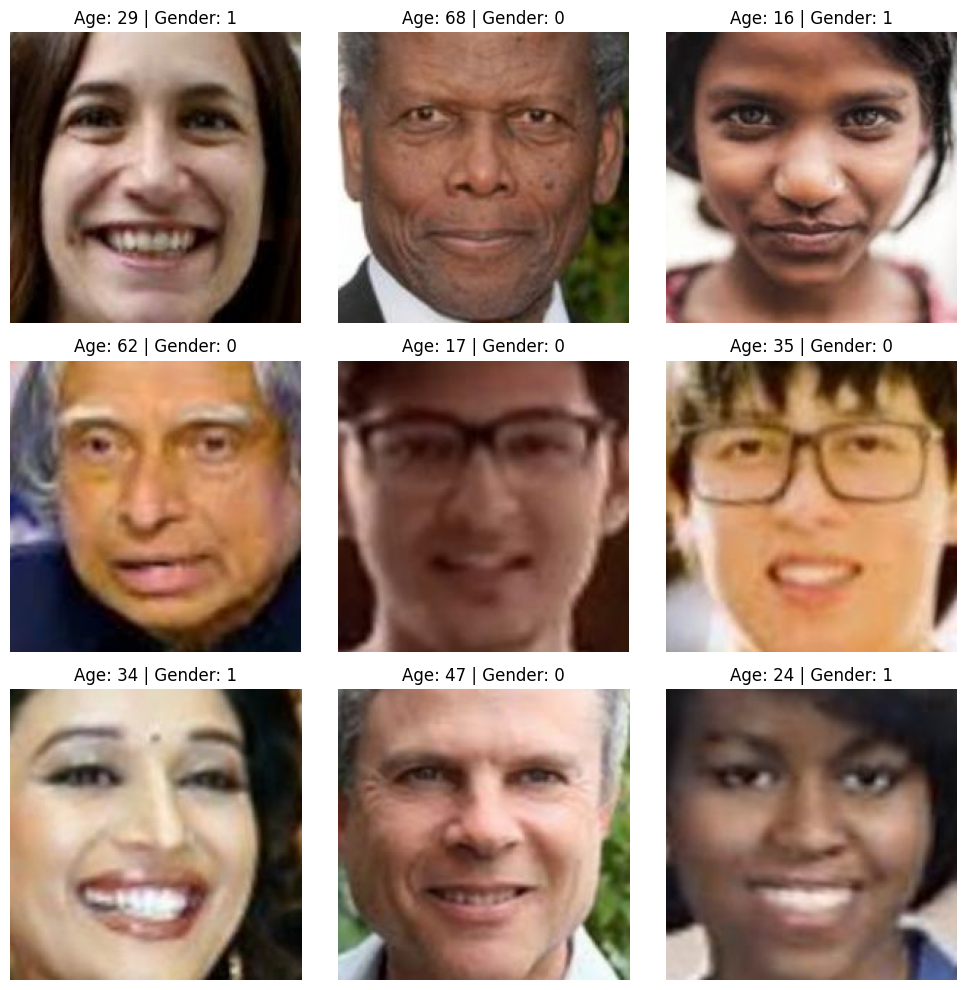

In [7]:
# Base folder containing all images
folder_path = "/kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped/UTKFace"

def show_sample_images(df, folder_path, n=9):
    # Randomly sample n rows
    sample_df = df.sample(n=n, random_state=None).reset_index(drop=True)

    plt.figure(figsize=(10, 10))

    for i, row in sample_df.iterrows():
        # Full image path
        img_path = os.path.join(folder_path, row["img"])

        # Read image
        img = plt.imread(img_path)

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Age: {row['age']} | Gender: {row['gender']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the function
show_sample_images(df, folder_path)

In [8]:
train = df.sample(frac=1,random_state=0).iloc[:20000]
test = df.sample(frac=1,random_state=0).iloc[20000:]

In [9]:
print('shapes: ')
print('train: ',train.shape)
print('test : ',test.shape)

shapes: 
train:  (20000, 3)
test :  (3708, 3)


In [10]:
# data augmentation

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_generator = train_datagen.flow_from_dataframe(
    train,
    directory=folder_path,
    x_col='img',
    y_col=['age','gender'],
    target_size=(200,200),
    batch_size=64,
    class_mode='multi_output'
)

test_generator = train_datagen.flow_from_dataframe(
    test,
    directory=folder_path,
    x_col='img',
    y_col=['age','gender'],
    target_size=(200,200),
    batch_size=64,
    class_mode='multi_output'
)

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [12]:
# wraping the output in a tupple because list is not excepted in keras latest model
def generator_wrapper(generator):
    while True:
        x, y = next(generator)

        # y is [age, gender]
        yield x, (y[0], y[1])

In [13]:
train_gen = generator_wrapper(train_generator)
test_gen = generator_wrapper(test_generator)

In [15]:
vggnet = VGG16(include_top=False,input_shape=(200,200,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [16]:
vggnet.trainable = False

output = vggnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512,activation='relu')(flatten)
dense2 = Dense(512,activation='relu')(flatten)

dense3 = Dense(512,activation='relu')(dense1)
dense4 = Dense(512,activation='relu')(dense2)

output1 = Dense(1,activation='linear',name='age')(dense3)
output2 = Dense(1,activation='sigmoid',name='gender')(dense4)

In [17]:
model = Model(inputs=vggnet.input,outputs=[output1,output2])

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 34,116,418 (130.14 MB)

 Trainable params: 19,401,730 (74.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

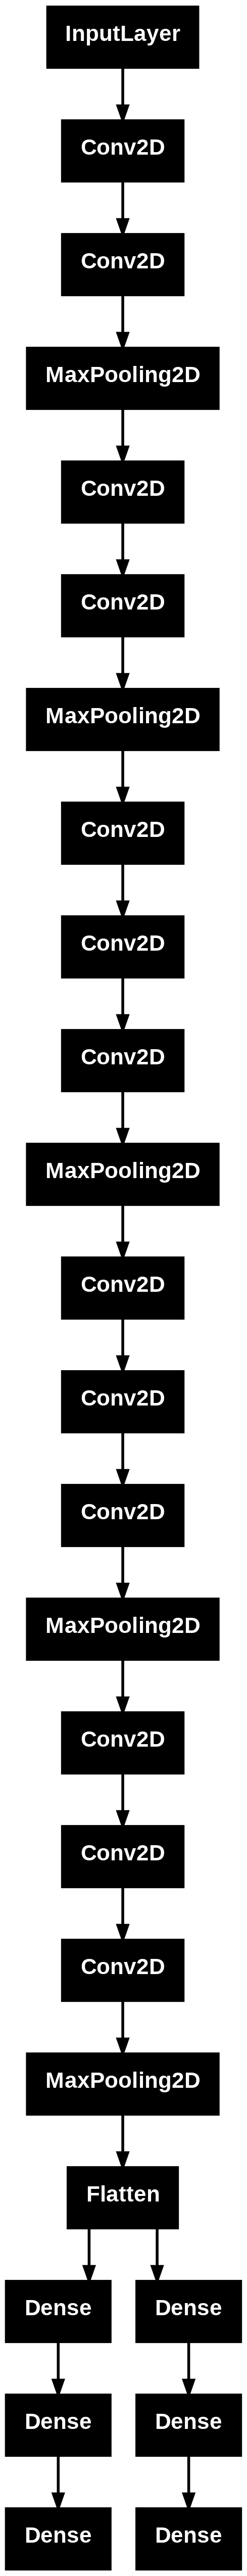

In [19]:
plot_model(model)

In [20]:
model.compile(optimizer='adam',loss={'age':'mae','gender':'binary_crossentropy'},metrics={'age':'mae','gender':'accuracy'},loss_weights={'age':1,'gender':99})

In [21]:
model.fit(
    train_gen,
    steps_per_epoch=len(train_generator),
    validation_data=test_gen,
    validation_steps=len(test_generator),
    epochs=10
)

Epoch 1/10
  1/313 ━━━━━━━━━━━━━━━━━━━━ 1:19:54 15s/step - age_loss: 33.9297 - age_mae: 33.9297 - gender_accuracy: 0.2656 - gender_loss: 0.8010 - loss: 113.2325

I0000 00:00:1785828041.016444     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - age_loss: 10.8872 - age_mae: 10.8889 - gender_accuracy: 0.7566 - gender_loss: 0.5238 - loss: 62.7705 - val_age_loss: 8.7086 - val_age_mae: 8.7100 - val_gender_accuracy: 0.8231 - val_gender_loss: 0.3873 - val_loss: 47.0552
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 213s 684ms/step - age_loss: 8.9119 - age_mae: 8.9116 - gender_accuracy: 0.8124 - gender_loss: 0.4063 - loss: 49.1085 - val_age_loss: 8.9018 - val_age_mae: 8.9035 - val_gender_accuracy: 0.8134 - val_gender_loss: 0.4025 - val_loss: 48.7607
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 212s 679ms/step - age_loss: 8.5710 - age_mae: 8.5713 - gender_accuracy: 0.8252 - gender_loss: 0.3792 - loss: 46.1182 - val_age_loss: 8.2617 - val_age_mae: 8.2608 - val_gender_accuracy: 0.8452 - val_gender_loss: 0.3562 - val_loss: 43.5321
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 211s 675ms/step - age_loss: 8.3265 - age_mae: 8.3249 - gender_accuracy: 0.8331 - gender_loss: 0.3623 - loss: 44.1648 - val_age_loss: 8.993

In [ ]:
plt.title('age_mae')
plt.plot(history.history['age_mae'],color='red',label='train')
plt.plot(history.history['val_age_mae'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
plt.title('gender_accuracy')
plt.plot(history.history['gender_accuracy'],color='red',label='train')
plt.plot(history.history['val_gender_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
plt.title('age_loss')
plt.plot(history.history['age_loss'],color='red',label='train')
plt.plot(history.history['val_age_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
plt.title('gender_loss')
plt.plot(history.history['gender_loss'],color='red',label='train')
plt.plot(history.history['val_gender_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
plt.title('Model_loss')
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()